## Приоритезация обращений. EDA

Провожу разведочный анализ данных. 

Исследую:
- [EDA 1.1](#eda11) --- пропуски, статистические аномалии, редкие значения, дубликаты, логические/физические аномалии (возраст < 0), несоответствия типов;
- [EDA 1.2](#eda12) --- совместные распределения и корреляции признаков;
- [EDA 1.3](#eda13) --- целевую переменную;
- [EDA 1.4](#eda14) --- временные зависимости;
- [EDA 1.5](#eda15) --- `events.csv` для использования его при генерации признаков;
- [EDA 1.6](#eda16) --- остальное...

### О задаче

Есть поток обращений, которые попадают в обработку операторам или партнерам. Для каждого обращения нужно заранее оценить вероятность успешного целевого действия в ближайшие **5 дней** после назначения.

Результат модели используется для ранжирования: более **перспективные** обращения должны получать более **высокий** score.

Одна строка соответствует одному назначенному обращению в конкретный момент времени. В строке собран контекст вокруг факта назначения обращения в обработку.

Признаки должны быть доступны на момент назначения обращения. Даже если в исторических данных есть информация, которая появилась позже, в реальном production-скоринге такой информации еще не будет. Поэтому использование признаков, которые появляются после назначения или напрямую описывают будущий исход, будет считаться читингом.

Если ты строишь признаки из **events.csv**, используй только события с **event_ts < assignment_ts**. В исторических событиях могут встречаться записи после назначения обращения, такие события недоступны модели в момент скоринга.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import math
from scipy.stats import chi2_contingency

In [2]:
# Пути к данным.
ROOT = Path(".")
DATA_DIR = ROOT / "data"
TARGET = "target"

# Эти колонки не используем как признаки модели.
ID_COLUMNS = {"lead_id", "user_id"}
TIME_COLUMNS = {"assignment_ts", "assignment_date"}
NON_FEATURE_COLUMNS = ID_COLUMNS | TIME_COLUMNS | {TARGET, "split"}

RANDOM_STATE = 42

Подгрузим датасеты `train.csv`, `test.csv` и `events.csv`.

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")

print("train:", train.shape)
print("test:", test.shape)
print("events:", events.shape)

train: (13694, 119)
test: (4306, 118)
events: (254705, 7)


In [4]:
target = train[TARGET]

### EDA1.1

Исключаем `lead_id`, `user_id`, `timestamps` и `target`.

`feature_columns` хранит стартовый набор признаков.
Отделим категориальные признаки от численных.

In [5]:
feature_columns = [
    column for column in train.columns
    if column not in NON_FEATURE_COLUMNS and column in test.columns
]

numeric_columns = [
    column for column in feature_columns
    if pd.api.types.is_numeric_dtype(train[column])
]

categorical_columns = [
    column for column in feature_columns
    if column not in numeric_columns
]

# числовые признаки, которые являются оконными признаками (окна по времени)
window_columns = [
    column for column in numeric_columns 
    if re.search(r'_\d+d$', column)
]

print("numeric:", len(numeric_columns))
print("numeric window:", len(window_columns))
print("categorical:", len(categorical_columns))
print("total features:", len(feature_columns))

numeric: 107
numeric window: 99
categorical: 7
total features: 114


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13694 entries, 0 to 13693
Columns: 119 entries, lead_id to target
dtypes: float64(107), int64(1), object(11)
memory usage: 12.4+ MB


##### Исследуем дубликаты

In [7]:
print(f"Количество полных дубликатов в train: {train.duplicated().sum()}")
print(f"Количество дубликатов без учета lead_id в train: {train.drop('lead_id', axis=1).duplicated().sum()}")
print(f"Количество дубликатов lead_id в train: {train['lead_id'].duplicated().sum()}")
print(f"Количество дубликатов (user_id, assignment_ts) в train: {train.duplicated(subset=['user_id', 'assignment_ts']).sum()}")

Количество полных дубликатов в train: 0
Количество дубликатов без учета lead_id в train: 0
Количество дубликатов lead_id в train: 0
Количество дубликатов (user_id, assignment_ts) в train: 0


##### Исследуем пропуски

In [8]:
nan_values = train.isna().sum().sort_values(ascending=False).where(lambda x: x > 0).dropna()
nan_values_df = pd.DataFrame({
    "NaN_values": nan_values,
    "NaN_values_rel": nan_values / len(train)
})
nan_values_df

,NaN_values,NaN_values_rel
seller_response_rate_30d,708.0,0.051701
leadgen_prev_positive_90d,452.0,0.033007
item_favorites_3d,451.0,0.032934
query_refinements_30d,446.0,0.032569
detail_expands_3d,445.0,0.032496
...,...,...
photo_swipes_14d,376.0,0.027457
search_views_7d,374.0,0.027311
call_clicks_90d,371.0,0.027092
leadgen_prev_positive_7d,358.0,0.026143


In [9]:
# Количество NaN в категориальных признаках
train[categorical_columns].isna().sum()

lead_source           0
call_center           0
region                0
car_segment           0
lead_channel          0
user_tenure_bucket    0
price_bucket          0
dtype: int64

##### Исследуем редкие значения в категориальных, дискретных и низкокардинальных числовых признаках

Разделим числовые признаки по смыслу и кардинальности разом (порог `CARDINALITY_THRESHOLD`):
- `discrete_numeric_columns` - дискретные признаки без суффикса `_[1/3/7/14/30/90]d` с низкой кардинальностью
- `low_cardinality_counters` - оконные счетчики (`_[1/3/7/14/30/90]d`) с низкой кардинальностью; для них IQR неинформативен, но редкие значения ищем тем же способом, что и для категориальных/дискретных
- `continuous_columns` - все остальное, для них ниже применяем IQR


Очевидно, низкокардинальные счетчики и числовые дискретные признаки можно было не делить, поскольку технически это одно и то же. Такое решение я принял, потому что посчитал полезным данное разделение по смыслу для дальнейшей работы с датасетом.

In [16]:
CARDINALITY_THRESHOLD = 15

In [17]:
numeric_nunique = train[numeric_columns].nunique().sort_values()
is_windowed_counter = numeric_nunique.index.isin(window_columns)

discrete_numeric_columns = numeric_nunique[(numeric_nunique < CARDINALITY_THRESHOLD) & ~is_windowed_counter].index.tolist()
low_cardinality_counters = numeric_nunique[(numeric_nunique < CARDINALITY_THRESHOLD) & is_windowed_counter].index.tolist()
continuous_columns = [
    column for column in numeric_columns
    if column not in discrete_numeric_columns and column not in low_cardinality_counters
]

print("discrete_numeric_columns:", discrete_numeric_columns)
print("low_cardinality_counters length:", len(low_cardinality_counters))
print("continuous_columns length:", len(continuous_columns))

discrete_numeric_columns: ['is_weekend', 'assignment_weekday', 'assignment_hour']
low_cardinality_counters length: 57
continuous_columns length: 47


In [18]:
train[categorical_columns].describe().T[["unique"]].sort_values(by="unique", ascending=True)

,unique
call_center,2
lead_source,3
user_tenure_bucket,3
price_bucket,3
car_segment,4
lead_channel,4
region,5


Исследую категориальные признаки и дискретные с низкой кардинальностью одинаково --- просто рассмотрю частоты их значений.

In [19]:
for column in categorical_columns + discrete_numeric_columns:
    print(train[column].value_counts(), end="\n\n")

lead_source
Model    5688
CRM      4839
Perf     3167
Name: count, dtype: int64

call_center
external    7882
voxys       5812
Name: count, dtype: int64

region
east       2796
west       2770
central    2725
north      2710
south      2693
Name: count, dtype: int64

car_segment
standard      5780
budget        4713
premium       1909
commercial    1292
Name: count, dtype: int64

lead_channel
web            3518
app            3408
retargeting    3385
partner        3383
Name: count, dtype: int64

user_tenure_bucket
warm     6175
new      4121
loyal    3398
Name: count, dtype: int64

price_bucket
mid     7076
low     4170
high    2448
Name: count, dtype: int64

is_weekend
0.0    10240
1.0     3454
Name: count, dtype: int64

assignment_weekday
2.0    2592
1.0    2552
5.0    1736
4.0    1731
6.0    1718
3.0    1713
0.0    1652
Name: count, dtype: int64

assignment_hour
13.0    1877
14.0    1786
16.0    1524
12.0    1489
15.0    1477
17.0    1326
11.0    1184
18.0     919
10.0     621
19.

**ВЫВОД**: редких или аномальных значений в категориальных признаках и дискретных с низкой кардинальностью --- НЕ ОБНАРУЖИЛ

Теперь рассмотрю низкокардинальные счетчики `low_cardinality_counters`.

Смотреть `value_counts()` глазами (тем более рисовать под каждый гистограмму) - не вариант, нужен автоматический критерий. **Рассуждения такие**: данные признаки должны иметь около Пуассоновские распределения (эвристика о том, что число редких независимых событий за фикс. окно --- это классический кейс для Пуассоновского распределения), т.е. частота значений отсортированных по возрастанию, должна монотонно убывать после моды. Проверю, что это так.

In [20]:
def check_poisson_monotonic(df, columns):
    results = []

    for col in columns:
        vc = df[col].value_counts().sort_index()
        counts = vc.values
        # монотонность должна соблюдаться не от значения 0, а от моды (пика) -
        # у Пуассона с лямбдой > 1 пик естественно смещен, рост к нему - не считается аномалия
        mode_idx = counts.argmax()
        tail_counts = counts[mode_idx:]
        violations = int((tail_counts[1:] > tail_counts[:-1]).sum())

        results.append({
            'column': col,
            'violations': violations,
            'is_monotonic': violations == 0,
            'n_unique': len(vc),
            'mode_value': vc.index[mode_idx],
            'max_value': vc.index[-1],
            'min_value': vc.index[0]
        })

    return pd.DataFrame(results)

monotonic_check = check_poisson_monotonic(train, low_cardinality_counters)
trouble_monotonic_counters = monotonic_check[monotonic_check['is_monotonic'] == False].sort_values(by='violations', ascending=False)
trouble_monotonic_counters

,column,violations,is_monotonic,n_unique,mode_value,max_value,min_value
49,leadgen_prev_assigned_30d,1,False,11,0.0,10.0,0.0
52,saved_search_matches_14d,1,False,12,0.0,11.0,0.0
54,call_clicks_30d,1,False,12,1.0,11.0,0.0
56,photo_swipes_3d,1,False,13,1.0,13.0,0.0


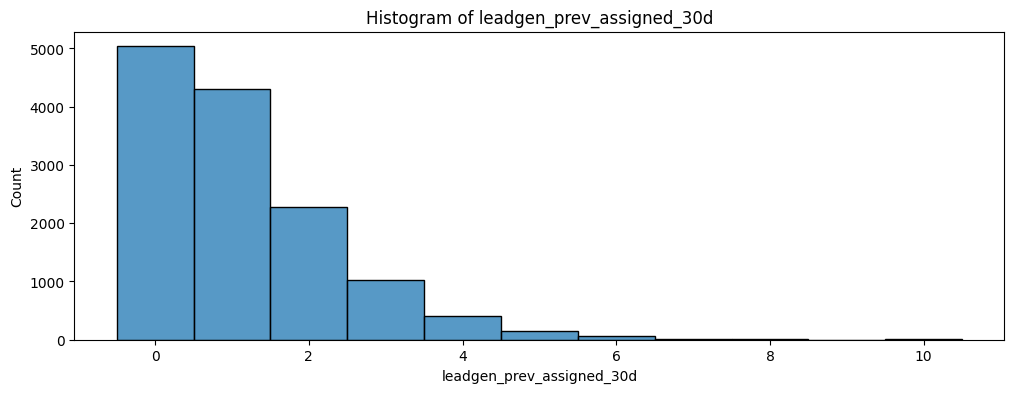

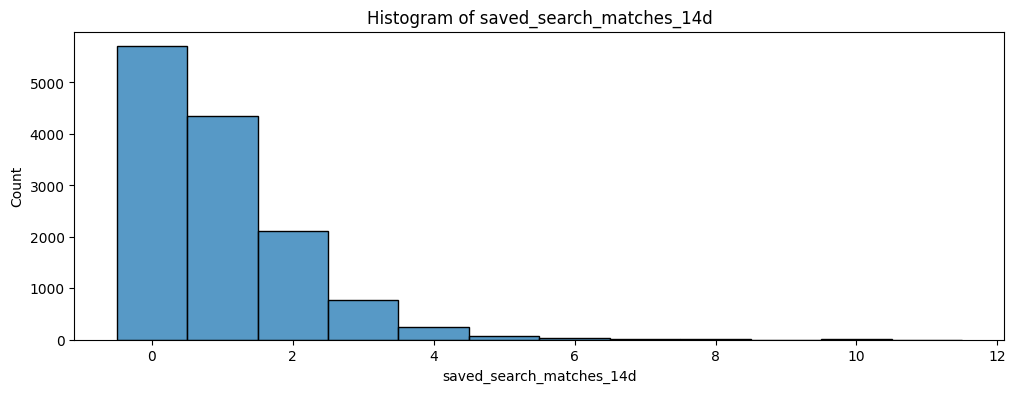

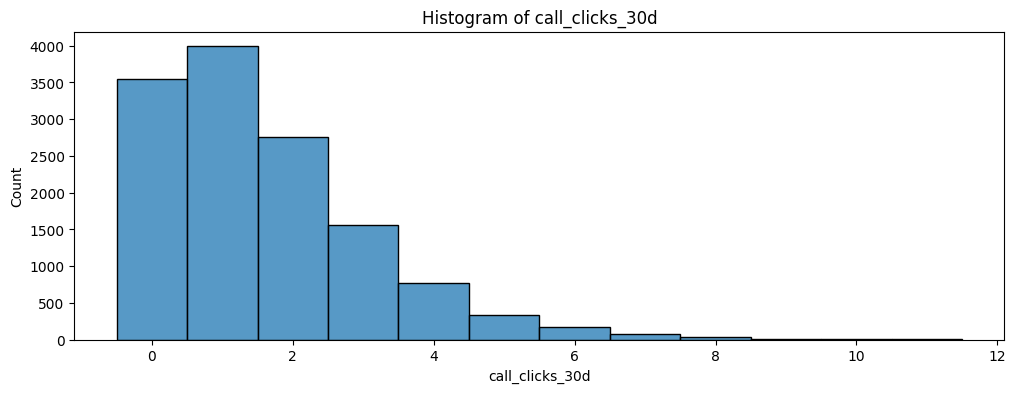

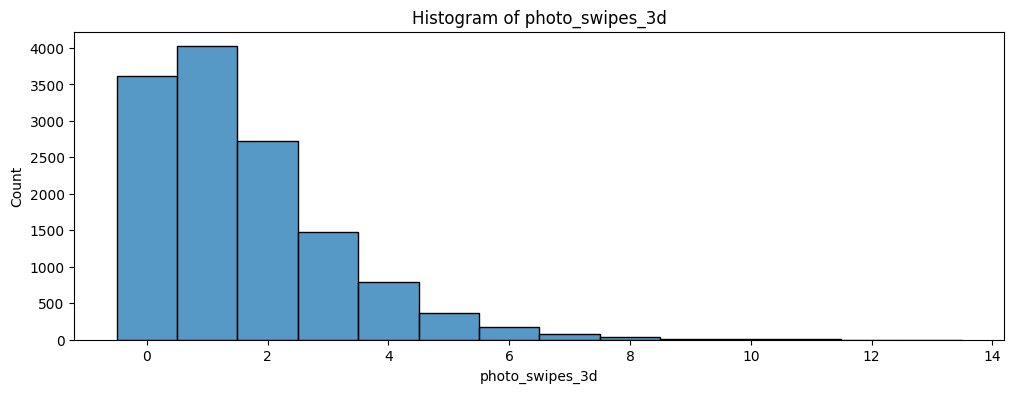

In [21]:
for column in train[trouble_monotonic_counters['column']]:
    plt.figure(figsize=(12, 4))
    sns.histplot(train[column], bins=range(int(train[column].min()), int(train[column].max()) + 2), discrete=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

```
были попытки менять CARD_THRESHOLD, вывод от этого никак не меняется
```

**ВЫВОД**: распределения выглядят корректно; статистических аномалий НЕ ОБНАРУЖИЛ (при небольших значениях частот есть отклонения от монотонности - но это допустимый шум в хвосте графика).

Также можно сделать вывод, что в датасете **нет проблемы несоответствия типов**.

##### Исследуем статистические аномалии (выбросы) в численных непрерывных признаках

Для поиска выбросов используем IQR на `continuous_columns` (непрерывные признаки) - `discrete_numeric_columns` и `low_cardinality_counters` туда не входят, потому что на таких узких окнах IQR неинформативен

In [22]:
def iqr_outlier_stats(df, columns):
    q1 = df[columns].quantile(0.1)
    q3 = df[columns].quantile(0.9)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    is_outlier = (df[columns] < lower_bound) | (df[columns] > upper_bound)
    return pd.DataFrame({
        "outliers_count": is_outlier.sum(),
        "outliers_share": is_outlier.mean()
    }).sort_values("outliers_share", ascending=False)

# для вывода абсолютного количества выбросов не забываю дропнуть NaN
outlier_stats = iqr_outlier_stats(train.dropna(), continuous_columns)
outlier_stats[outlier_stats["outliers_share"] > 0].head(10)

,outliers_count,outliers_share
seller_page_views_7d,7,0.009669
user_age_days,3,0.004144
seller_inventory_count,2,0.002762
photo_swipes_14d,2,0.002762
seller_page_views_14d,2,0.002762
item_views_14d,2,0.002762
item_favorites_30d,1,0.001381
item_favorites_90d,1,0.001381
query_refinements_14d,1,0.001381
search_views_30d,1,0.001381


Визуализируем boxplot-ами признаки с наибольшей долей выбросов по IQR. 

```
В названии графиков в скобках после признака стоит значение кардинальности
```

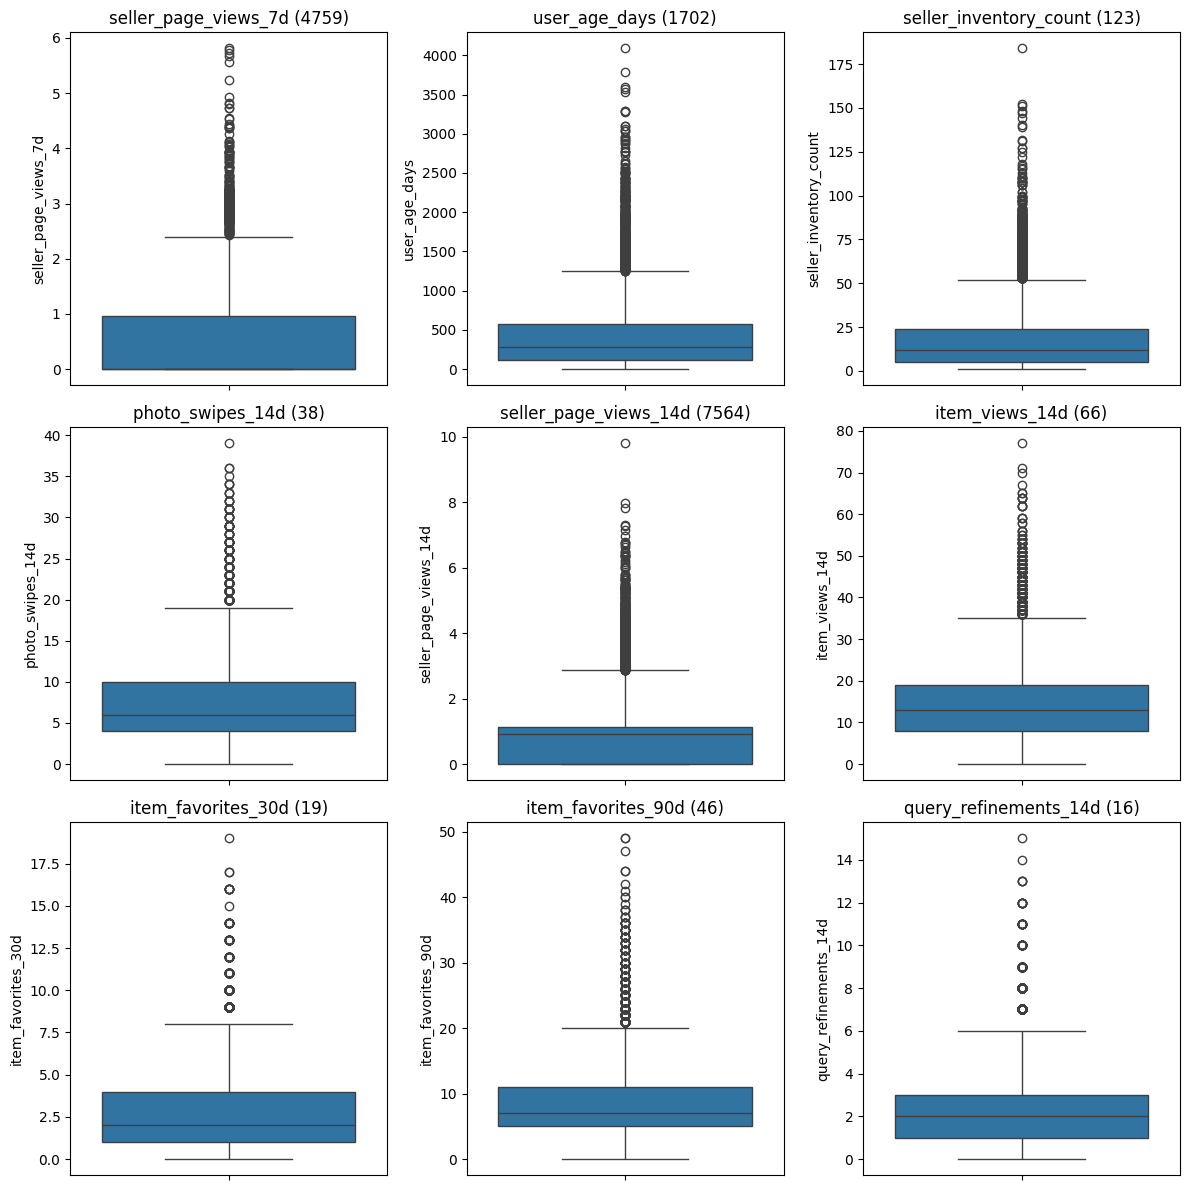

In [23]:
# рисуем топ-9 признаков с наибольшей долей выбросов
top_outlier_columns = outlier_stats[outlier_stats["outliers_share"] > 0].head(9).index.tolist()

n_cols = 3
n_rows = math.ceil(len(top_outlier_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()
for i, column in enumerate(top_outlier_columns):
    sns.boxplot(y=train[column], ax=axes[i])
    axes[i].set_title(f"{column} ({train[column].nunique()})")

plt.tight_layout()
plt.show()

##### Исследуем физические/логические аномалии (возраст < 0)

Логика датасета имеет несколько ограничений:
- нет отрицательных значений в числовых признаках (очевидный вывод в связи с логикой признаков)
- `assignment_weekday` должен быть согласован с `is_weekend` и быть в [0, 6];
- `seller_response_rate_30d` - это rate, должен быть в [0, 1];
- вложенность окон: большее окно физически должно включать меньшее, т.е. для любого счетчика `_1d <= _3d <= _7d <= _14d <= _30d <= _90d`;
- воронка назначений: `leadgen_prev_positive_[N]d <= leadgen_prev_answered_[N]d <= leadgen_prev_assigned_[N]d` (нельзя получить положительный исход без ответа, ответить без назначения).

In [24]:
print(f"число строк, где все значения признаков вне [0, inf): {(train[numeric_columns] < 0).sum().sum()}")
print(f"число строк, где assignment_weekday вне [0, 6]: {(~train.assignment_weekday.between(0, 6)).sum()}")

is_weekend_expected = train.assignment_weekday.isin([5, 6]).astype(int)
print(f"число строк, где is_weekend не согласован с assignment_weekday: {(train.is_weekend != is_weekend_expected).sum()}")

rate = train.seller_response_rate_30d.dropna()
print(f"число строк, где seller_response_rate_30d вне [0, 1]: {(~rate.between(0, 1)).sum()}")

число строк, где все значения признаков вне [0, inf): 0
число строк, где assignment_weekday вне [0, 6]: 0
число строк, где is_weekend не согласован с assignment_weekday: 0
число строк, где seller_response_rate_30d вне [0, 1]: 0


- Используем функции `pairwise_violation_stats`, `row_violation_summary` и `violations_by_window` для подсчета статистики нарушений;
- Функция `plot_violations_by_window` строит гистограмму по доле нарушений в зависимости от размера/перехода окна


In [25]:
def pairwise_violation_stats(df, pairs):
    rows = []
    for lower, upper in pairs:
        # не забываю дропнуть NaN, иначе будет неверная доля нарушений
        pair_df = df[[lower, upper]].dropna()
        violations = int((pair_df[lower] > pair_df[upper]).sum())
        rows.append({
            "lower": lower,
            "upper": upper,
            "violations": violations,
            "violations_share": violations / len(pair_df),
        })
    return pd.DataFrame(rows).sort_values("violations_share", ascending=False)

def violations_by_window(pair_stats):
    # у lower/upper либо одно окно на пару (воронка), либо переход между двумя окнами (вложенность)
    def window_label(row):
        w1 = re.search(r'_(\d+d)$', row["lower"]).group(1)
        w2 = re.search(r'_(\d+d)$', row["upper"]).group(1)
        return w1 if w1 == w2 else f"{w1}->{w2}"

    labeled = pair_stats.assign(window=pair_stats.apply(window_label, axis=1))
    summary = labeled.groupby("window").agg(
        n_pairs=("violations", "size"),
        pairs_with_violations=("violations", lambda s: int((s > 0).sum())),
        mean_violations_share=("violations_share", "mean"),
    )
    # сортируем не по величине, а по естественному порядку окон - иначе тренд по размеру окна не виден
    order = sorted(summary.index, key=lambda label: WINDOW_ORDER.index(label.split("->")[0]))
    return summary.loc[order]

def plot_violations_by_window(pair_stats, label):
    summary = violations_by_window(pair_stats)
    plt.figure(figsize=(6, 3))
    plt.bar(summary.index, summary["mean_violations_share"])
    plt.title(f"[{label}] нарушения по размеру/переходу окна")
    plt.ylabel("mean violations_share")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def row_violation_summary(df, pairs, label):
    pair_stats = pairwise_violation_stats(df, pairs)
    total_checked = sum(len(df[[lower, upper]].dropna()) for lower, upper in pairs)
    total_violations = pair_stats["violations"].sum()

    # для каждой строки считаем, в скольких из pairs она нарушает ограничение
    # (NaN в сравнении дает False, т.е. пары с пропуском просто не считаются нарушением)
    violation_count_per_row = pd.Series(0, index=df.index)
    for lower, upper in pairs:
        violation_count_per_row += (df[lower] > df[upper]).astype(int)

    clean_rows = (violation_count_per_row == 0).sum()

    print(f"[{label}] нарушений от всех проверенных пар: {total_violations / total_checked:.2%}")
    print(f"[{label}] строк без единого нарушения: {clean_rows} ({clean_rows / len(df):.2%})")
    print(violation_count_per_row.describe())
    plot_violations_by_window(pair_stats, label)

    return pair_stats, violation_count_per_row


WINDOW_ORDER = ["1d", "3d", "7d", "14d", "30d", "90d"]

**Вложенность окон**: для одного и того же счетчика окно большего размера физически включает окно меньшего размера, значит `_1d ≤ _3d ≤ _7d ≤ _14d ≤ _30d ≤ _90d`

[вложенность окон] нарушений от всех проверенных пар: 9.62%
[вложенность окон] строк без единого нарушения: 5 (0.04%)
count    13694.000000
mean         7.242223
std          2.271108
min          0.000000
25%          6.000000
50%          7.000000
75%          9.000000
max         16.000000
dtype: float64


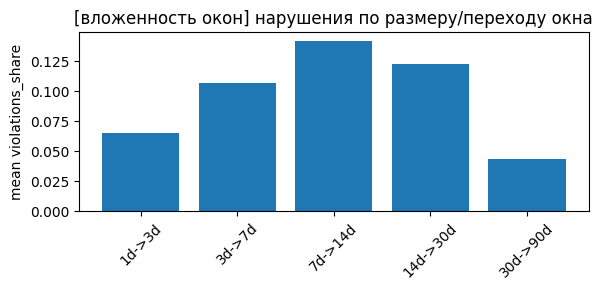

,lower,upper,violations,violations_share
68,seller_page_views_14d,seller_page_views_30d,2961,0.230410
67,seller_page_views_7d,seller_page_views_14d,2776,0.215662
2,active_days_auto_7d,active_days_auto_14d,2289,0.177842
17,detail_expands_7d,detail_expands_14d,2286,0.177278
77,user_contacts_7d,user_contacts_14d,2284,0.176821
...,...,...,...,...
41,leadgen_prev_positive_3d,leadgen_prev_positive_7d,202,0.015632
40,leadgen_prev_positive_1d,leadgen_prev_positive_3d,166,0.012894
74,similar_item_clicks_30d,similar_item_clicks_90d,138,0.010699
49,photo_swipes_30d,photo_swipes_90d,13,0.001009


In [26]:
# все префиксы для оконных признаков (без суффикса _[N]d)
windowed_prefixes = sorted({re.sub(r'_\d+d$', '', column) for column in window_columns})
nesting_pairs = [
    (f"{prefix}_{w1}", f"{prefix}_{w2}")
    for prefix in windowed_prefixes
    for w1, w2 in zip(WINDOW_ORDER, WINDOW_ORDER[1:])
    if f"{prefix}_{w1}" in train.columns and f"{prefix}_{w2}" in train.columns
]
nesting_violations, _ = row_violation_summary(train, nesting_pairs, "вложенность окон")
nesting_violations[nesting_violations["violations"] > 0]

**Воронка назначений**: положительный исход невозможен без ответа, ответ невозможен без назначения, т.е. `leadgen_prev_positive_[N]d ≤ leadgen_prev_answered_[N]d ≤ leadgen_prev_assigned_[N]d`

[воронка назначения] нарушений от всех проверенных пар: 5.44%
[воронка назначения] строк без единого нарушения: 7343 (53.62%)
count    13694.000000
mean         0.614941
std          0.769431
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          5.000000
dtype: float64


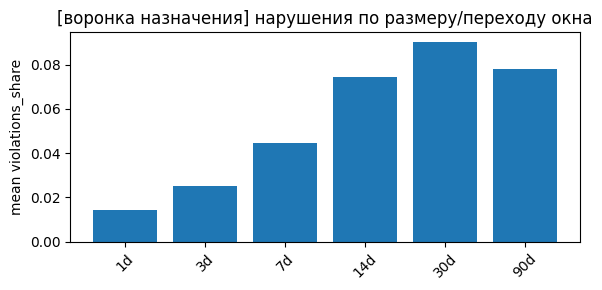

,lower,upper,violations,violations_share
10,leadgen_prev_positive_90d,leadgen_prev_answered_90d,1423,0.110938
9,leadgen_prev_answered_30d,leadgen_prev_assigned_30d,1254,0.097126
7,leadgen_prev_answered_14d,leadgen_prev_assigned_14d,1224,0.094744
8,leadgen_prev_positive_30d,leadgen_prev_answered_30d,1075,0.083082
5,leadgen_prev_answered_7d,leadgen_prev_assigned_7d,818,0.063613
6,leadgen_prev_positive_14d,leadgen_prev_answered_14d,701,0.054228
11,leadgen_prev_answered_90d,leadgen_prev_assigned_90d,578,0.044918
3,leadgen_prev_answered_3d,leadgen_prev_assigned_3d,447,0.034622
4,leadgen_prev_positive_7d,leadgen_prev_answered_7d,335,0.025899
1,leadgen_prev_answered_1d,leadgen_prev_assigned_1d,203,0.015746


In [27]:
leadgen_pairs = [
    pair
    for window in WINDOW_ORDER
    for pair in [
        (f"leadgen_prev_positive_{window}", f"leadgen_prev_answered_{window}"),
        (f"leadgen_prev_answered_{window}", f"leadgen_prev_assigned_{window}"),
    ]
]

leadgen_violations, _ = row_violation_summary(train, leadgen_pairs, "воронка назначения")
leadgen_violations[leadgen_violations["violations"] > 0]

**ВЫВОД**: существенное число нарушений в проверках вложенности окон и воронке назначения. Каждая из гистограмм нарушений не похожа на случайный шум, скорее всего что-то не так с пайплайном расчета признаков. Возможное решение проблемы - пересчитать вручную с использованием `events.csv`.

### EDA1.2

##### Исследуем корреляцию числовых признаков

Считаю корреляцию Спирмена для всех числовых признаков `numeric_columns`. Используем именно корреляцию Спирмена, а не Пирсона, так как:
1) ранговая корреляция устойчива к аномалиям (а в EDA1.1 они нашлись у непрерывных признаков) и к скошенности счетчиков
2) улавливает любую монотонную связь, а не только линейную

In [28]:
CORR_THRESHOLD = 0.8

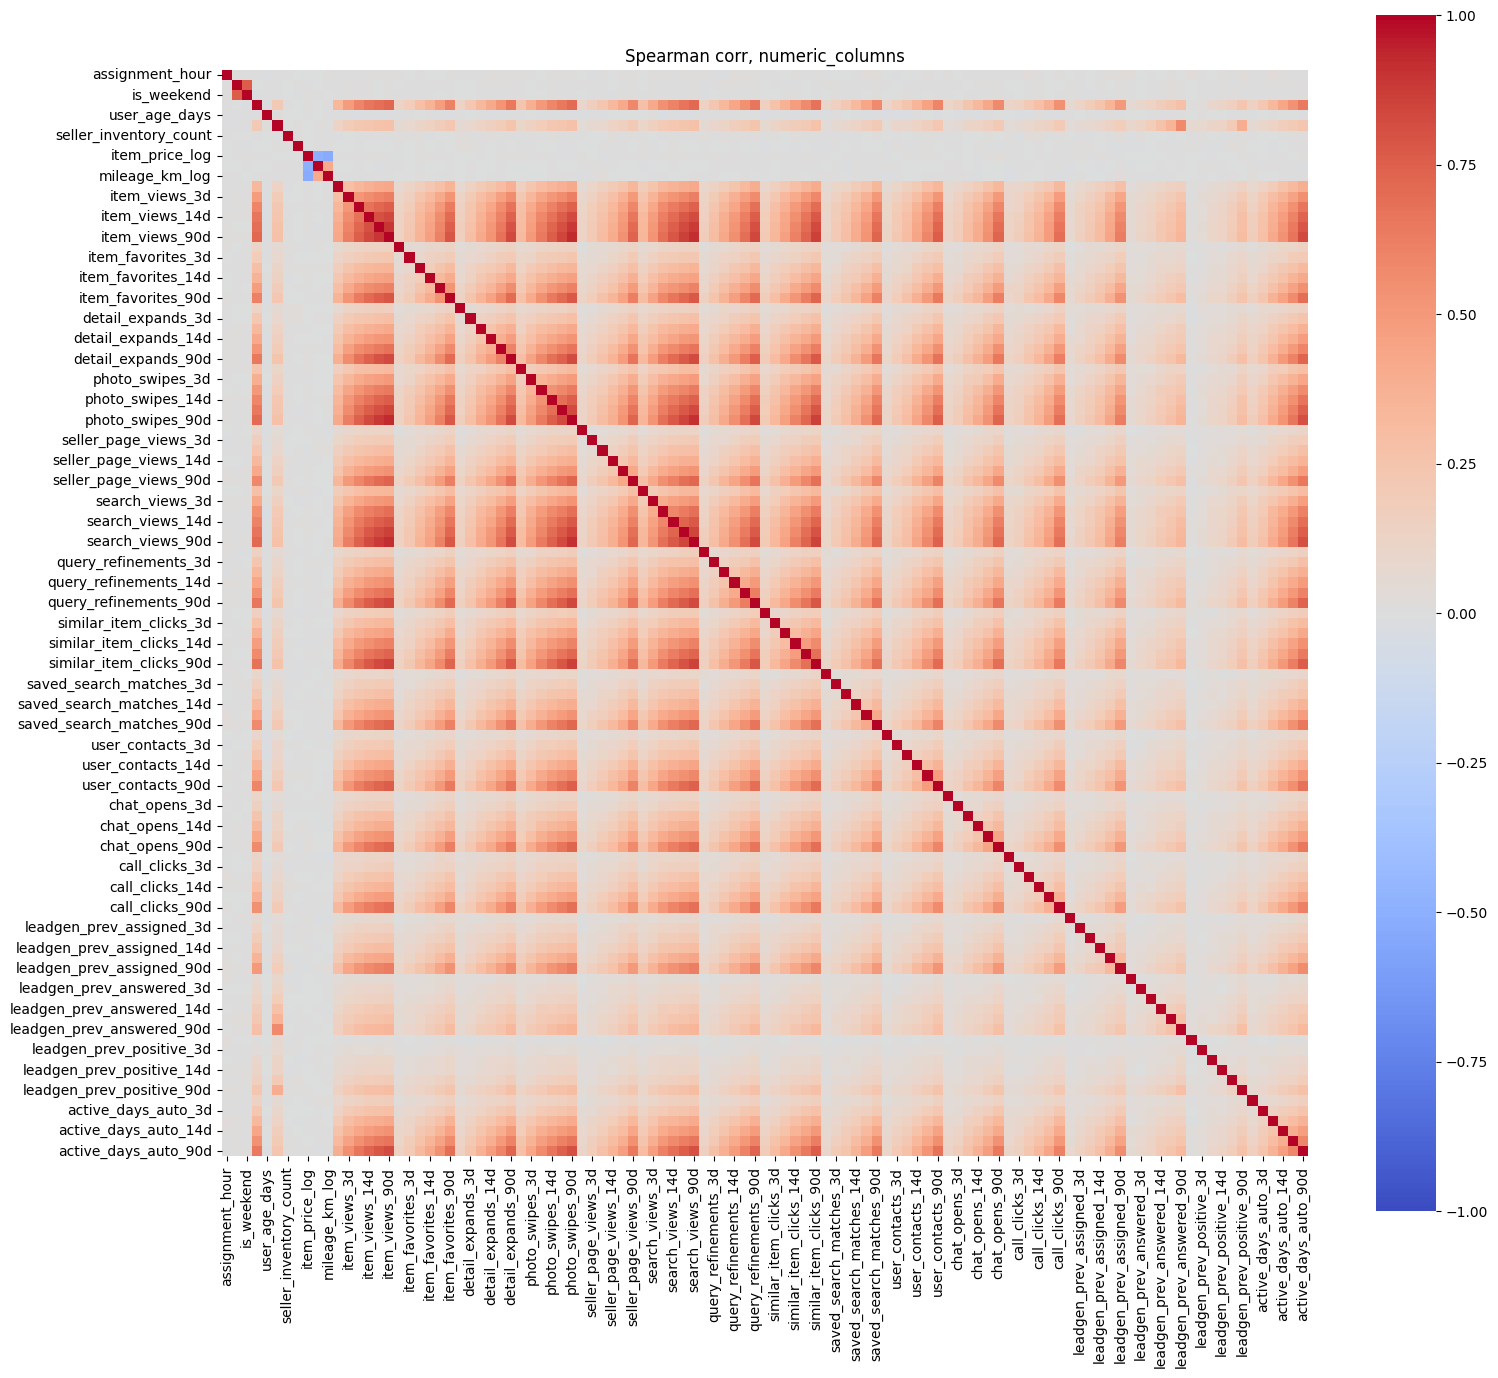

In [29]:
corr_matrix = train[numeric_columns].corr(method="spearman")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Spearman corr, numeric_columns")
plt.tight_layout()
plt.show()

Вытащим только пары с абсолютным значением корреляции > 0.8

In [32]:
# берем только верхний треугольник матрицы, чтобы не дублировать пары (a,b) и (b,a)
upper_triangle_mask = pd.DataFrame(
    [[i < j for j in range(len(corr_matrix))] for i in range(len(corr_matrix))],
    index=corr_matrix.index, columns=corr_matrix.columns
)
high_corr = corr_matrix.where(upper_triangle_mask).stack()
high_corr = high_corr[high_corr.abs() > CORR_THRESHOLD].sort_values(key=abs, ascending=False)
high_corr.head(20)

item_views_90d      photo_swipes_90d           0.933759
                    search_views_90d           0.929720
photo_swipes_90d    search_views_90d           0.921768
item_views_30d      item_views_90d             0.913850
                    photo_swipes_90d           0.903433
                    search_views_90d           0.899130
item_views_90d      similar_item_clicks_90d    0.889969
photo_swipes_90d    similar_item_clicks_90d    0.889894
item_views_90d      search_views_30d           0.884004
search_views_90d    similar_item_clicks_90d    0.880417
photo_swipes_90d    search_views_30d           0.877964
search_views_30d    search_views_90d           0.876459
item_views_90d      photo_swipes_30d           0.869365
photo_swipes_90d    query_refinements_90d      0.868353
item_views_90d      query_refinements_90d      0.866086
item_views_14d      item_views_90d             0.864933
item_views_90d      detail_expands_90d         0.863743
item_views_30d      similar_item_clicks_90d    0

**ВЫВОД:** Не трудно заметить, и из heatmap, и из таблицы, что высококоррелированные признаки почти всегда получены с использованием 90-дневного окна. Это легко объяснить --- чем больше окно, тем больше действий будет сделано за это окно.

Построим корреляционную матрицу для всех числовых не-оконных признаков (формально матрица построена лишь с целью приблизить синие ячейки с прошлой картинки).

`is_weekend` исключаю из этой матрицы: между ним и `assignment_weekday` уже известна детерминированная связь (проверено в EDA1.1 --- 0 несовпадений + подтверждено ниже), и в отличие от `assignment_weekday`, у `is_weekend` нет порядка (бинарный флаг) --- считаю его категориальным и применю к нему V Крамера позднее.

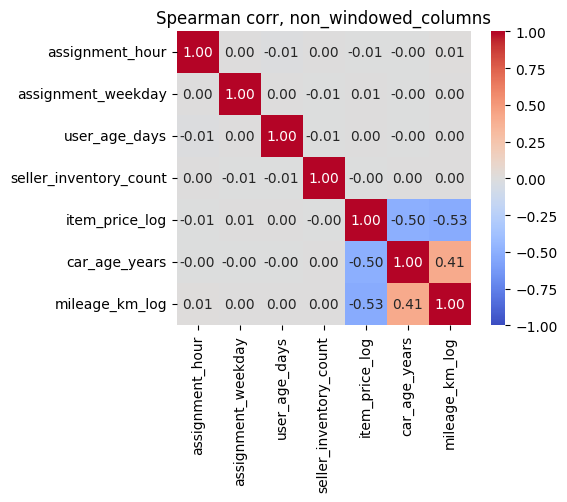

In [33]:
non_windowed_columns = [
    column for column in numeric_columns
    if column not in window_columns and column != "is_weekend"
]

corr_matrix_nonwindowed = train[non_windowed_columns].corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix_nonwindowed, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", square=True)
plt.title("Spearman corr, non_windowed_columns")
plt.tight_layout()
plt.show()

Итак, отрицательную корреляцию (синие ячейки) тут легко объяснить - чем старше автомобиль `car_age_years` и выше пробег `mileage_km_log`, тем он дешевле `item_price_log`.

##### Исследуем корреляцию категориальных признаков

Для категориальных признаков `categorical_columns` корреляция Пирсона/Спирмена не применима (нет порядка) - используем V Крамера.

+ Имеем 1 бинарный признак `is_weekend` (считаю его тоже категориальным).

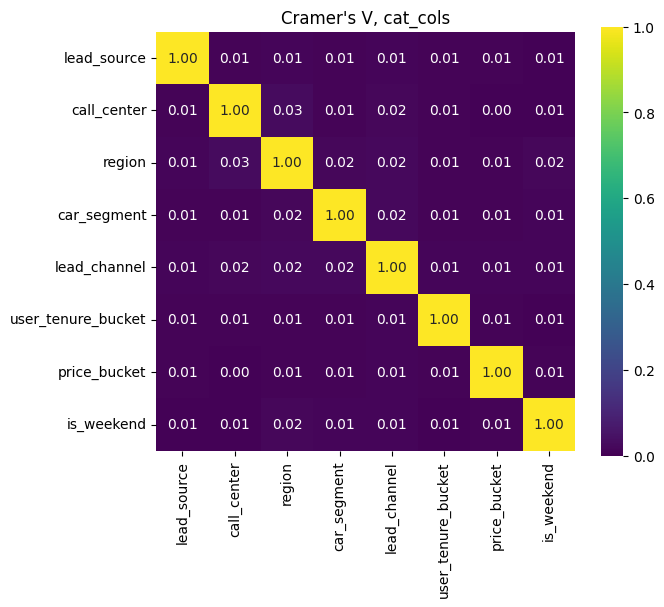

In [38]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    return (chi2 / (n * min_dim)) ** 0.5

cat_cols = categorical_columns + ['is_weekend']
cramers_v_matrix = pd.DataFrame(
    [[cramers_v(train[col_a], train[col_b]) for col_b in cat_cols] for col_a in cat_cols],
    index=cat_cols, columns=cat_cols
)

plt.figure(figsize=(7, 6))
sns.heatmap(cramers_v_matrix, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", square=True)
plt.title("Cramer's V, cat_cols")
plt.tight_layout()
plt.show()

Подтверждение линейной зависимости между `assignment_weekday` и `is_weekend`.

In [37]:
print(f"Cramer's V(assignment_weekday, is_weekend): {cramers_v(train['assignment_weekday'], train['is_weekend']):.3f}")

Cramer's V(assignment_weekday, is_weekend): 1.000


**ВЫВОД**: признаки `is_weekend` и `assignment_weekday` линейно зависимы --- один из них лишний.

##### Исследуем корреляцию категориальных признаков и числовых неоконных

**correlation ratio** - аналог V Крамера, но для пары "категориальный <-> числовой".

In [39]:
# используется ниже и в EDA1.3
def correlation_ratio(categorical, numeric):
    df = pd.DataFrame({"cat": categorical, "num": numeric}).dropna()
    group_means = df.groupby("cat")["num"].mean()
    group_sizes = df.groupby("cat")["num"].size()
    overall_mean = df["num"].mean()
    ss_between = (group_sizes * (group_means - overall_mean) ** 2).sum()
    ss_total = ((df["num"] - overall_mean) ** 2).sum()
    return (ss_between / ss_total) ** 0.5

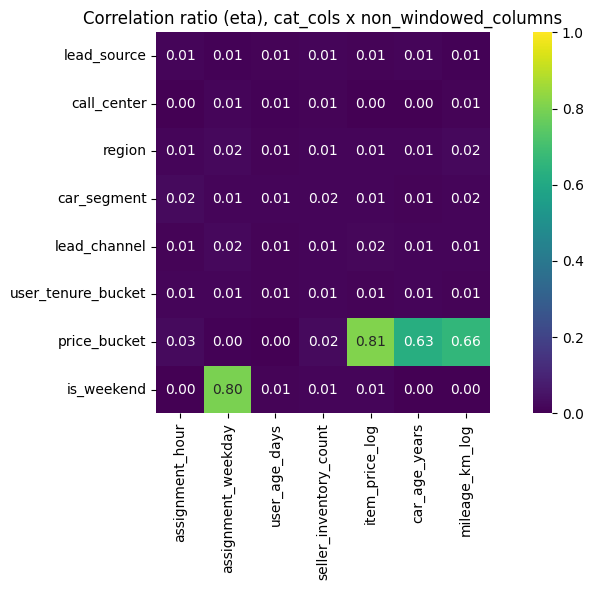

In [ ]:
# оконные счетчики по смыслу счетчики активности не связаны с категориями лида/товара
eta_matrix = pd.DataFrame(
    [[correlation_ratio(train[cat_column], train[num_column]) for num_column in non_windowed_columns]
     for cat_column in cat_cols],
    index=cat_cols, columns=non_windowed_columns
)

plt.figure(figsize=(9, 6))
sns.heatmap(eta_matrix, cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", square=True)
plt.title("Correlation ratio, cat_cols x non_windowed_columns")
plt.tight_layout()
plt.show()

**ВЫВОД**: значимых связей (`corr_rate` > 0.8)всего две, обе объяснимые.
1) связь между `is_weekend` и `assignment_weekday` уже была описана ранее
2) связь между `price_bucket` и `item_price_log`. `price_bucket` --- это по сути грубая цена, дублирует `item_price_log` => один из двух лишний. Связь при этом **не детерминированная**: границы бакетов перекрываются (`low` 11.20-13.72, `mid` 11.76-14.37, `high` 12.64-14.93), т.е. бакет считался не строго по `item_price_log`. 


### EDA1.3

Проведем анализ целевой переменной.

##### Исследуем баланс классов

target
0    10853
1     2841
Name: count, dtype: int64

доля target=1: 20.75%


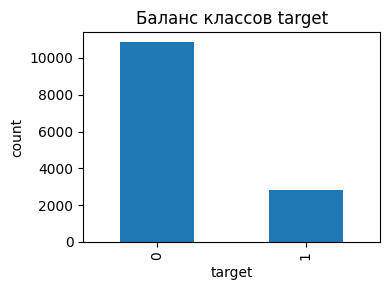

In [41]:
print(target.value_counts())
print(f"\nдоля target=1: {target.mean():.2%}")

plt.figure(figsize=(4, 3))
target.value_counts().sort_index().plot.bar()
plt.title("Баланс классов target")
plt.xlabel("target")
plt.ylabel("count")
plt.tight_layout()
plt.show()

**ВЫВОД**: заметный дисбаланс классов --- учесть при выборе метрики и обучении модели.

##### Исследуем корреляцию target с категориальными признаками и числовыми дискретными с низкой кардинальностью


Смотрю `conversion rate` по каждой категории --- какие сегменты дают долю успешных обращений выше/ниже среднего (красная линия на графиках). 

Дополнительно считаю V Крамера для ранжирования признаков по силе связи с target, т.к. target бинарный/номинальный (та же логика, что и в [EDA1.2](#eda12)).

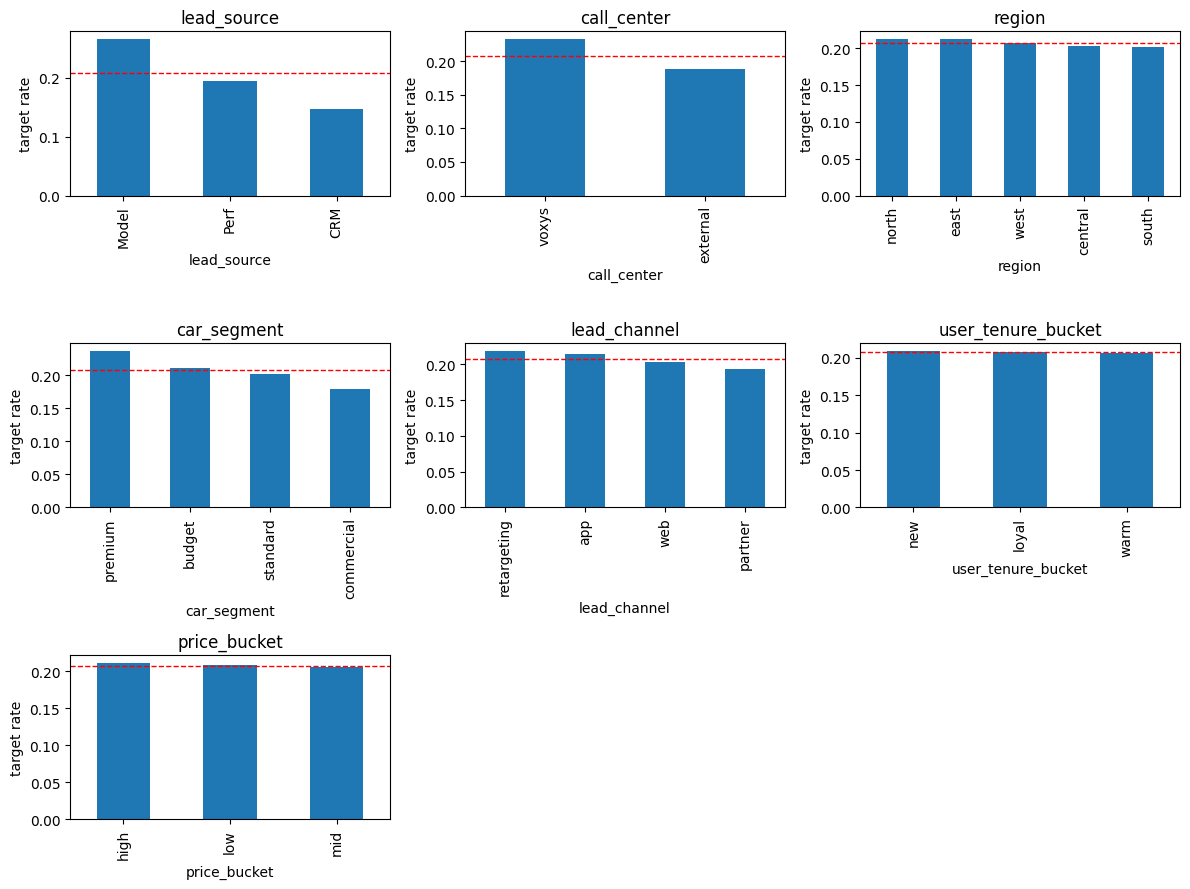

Ранжирование признаков по V Крамера относительно target


lead_source           0.127973
call_center           0.053461
car_segment           0.035866
assignment_hour       0.029072
lead_channel          0.024247
assignment_weekday    0.020871
region                0.011117
is_weekend            0.007496
price_bucket          0.004807
user_tenure_bucket    0.002773
Name: cramers_v, dtype: float64

In [42]:
def plot_target_rate_by_group(columns, n_cols=3, sort_by_rate=True):
    n_rows = math.ceil(len(columns) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()
    for i, column in enumerate(columns):
        rate = train.groupby(column)[TARGET].mean()
        rate = rate.sort_values(ascending=False) if sort_by_rate else rate.sort_index()
        rate.plot.bar(ax=axes[i])
        axes[i].axhline(target.mean(), color="red", linestyle="--", linewidth=1)
        axes[i].set_title(column)
        axes[i].set_ylabel("target rate")
    for ax in axes[len(columns):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_target_rate_by_group(categorical_columns)

cat_target_assoc = pd.Series(
    {column: cramers_v(train[TARGET], train[column]) for column in categorical_columns + discrete_numeric_columns},
    name="cramers_v"
).sort_values(ascending=False)
print("Ранжирование признаков по V Крамера относительно target")
cat_target_assoc

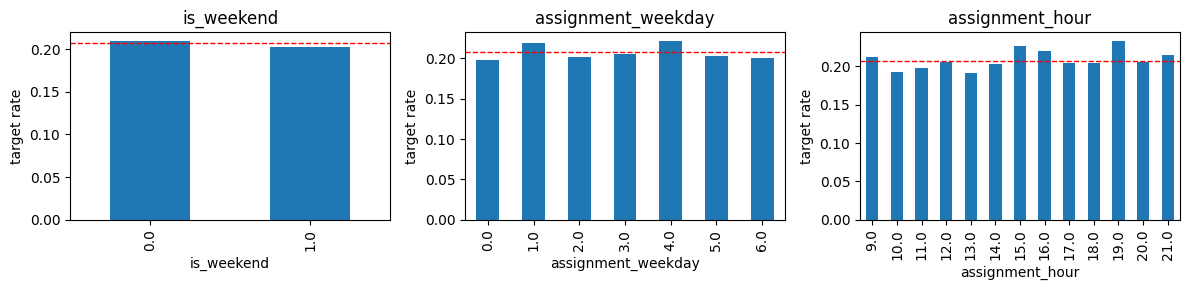

In [43]:
# discrete_numeric_columns порядковые (час/день недели) - не сортируем по величине, сохраняем естественный порядок
plot_target_rate_by_group(discrete_numeric_columns, sort_by_rate=False)

**ВЫВОД**: дискретные числовые признаки с низкой кардинальностью распределены примерно равномерно относительно каждой группы целевой переменной --- по V Крамера довольно слабо => назначение обращения почти не связано с исходом.

Среди самих категориальных признаков картина неоднородная: `lead_source` (0.13) и `call_center` (0.05) дают заметный разброс conversion rate по категориям (`Model` 26.5% vs `CRM` 14.8%; `voxys` 23.3% vs `external` 18.9%) --- источник и канал обработки лида реально влияют на исход. Остальные (`car_segment`, `lead_channel`, `region`, `price_bucket`, `user_tenure_bucket`) --- V Крамера < 0.04, бары почти не отклоняются от красной линии --- практически неинформативны для target.

##### Исследуем корреляцию target и оконных признаков

Используем **correlation ratio** --- аналог Cramér's V по смыслу, но для пары номинальный-непрерывный

In [ ]:
target_corr_ratio = pd.Series(
    {column: correlation_ratio(train[TARGET], train[column]) for column in window_columns},
    name="correlation_ratio"
).sort_values(ascending=False)
target_corr_ratio.head(15)

**ВЫВОД**: среди оконных признаков сильнее всего с target связаны признаки, расчитанные на длинных окнах (`search_views_90d`, `item_views_90d/30d/14d`, `photo_swipes_30d`, `active_days_auto_90d`, около 0.22-0.27) --- логично: чем активнее лид, тем выше шанс успешного исхода. Но именно эти признаки в EDA1.2 сильнее всего коррелируют между собой (|corr| > 0.8 на 90d-окне) --- при отборе признаков для модели стоит выбрать несколько главных, а не тащить все дублирующие сигналы.

##### Исследуем корреляцию target и неоконных числовых признаков с высокой кардинальностью

Метрика та же --- **correlation ratio**, т.к. target бинарный, а признаки непрерывные. Дополнительно рисую boxplot по классам target: если связи нет, коробки будут визуально совпадать.

user_age_days             0.011058
mileage_km_log            0.005475
item_price_log            0.004367
car_age_years             0.003500
seller_inventory_count    0.001914
Name: correlation_ratio, dtype: float64


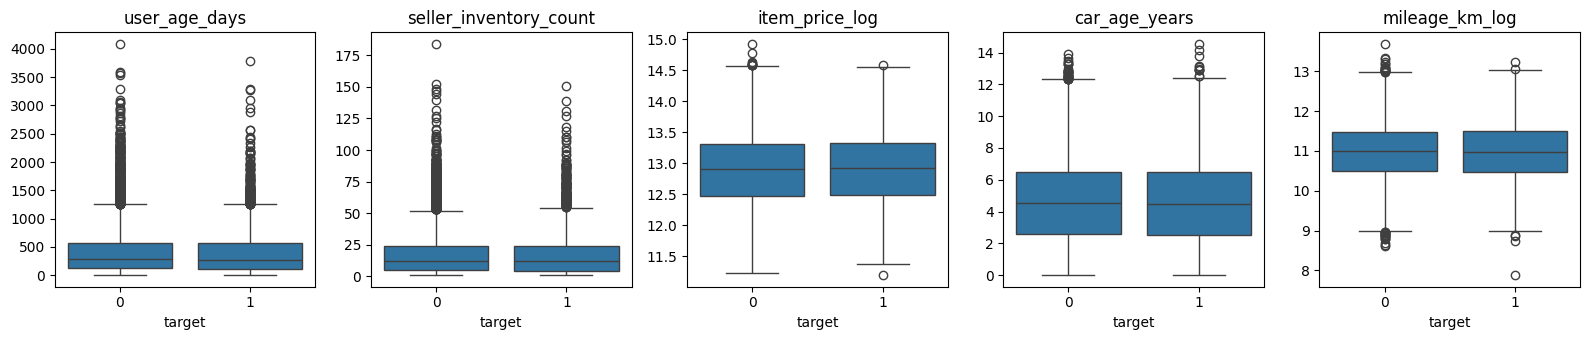

In [41]:
# из неоконных числовых убираем дискретные (час/день недели) - они уже прошли по V Крамера выше
non_windowed_continuous = [
    column for column in non_windowed_columns
    if column not in discrete_numeric_columns
]

target_corr_ratio_nonwindowed = pd.Series(
    {column: correlation_ratio(train[TARGET], train[column]) for column in non_windowed_continuous},
    name="correlation_ratio"
).sort_values(ascending=False)
print(target_corr_ratio_nonwindowed)

fig, axes = plt.subplots(1, len(non_windowed_continuous), figsize=(3.2 * len(non_windowed_continuous), 3.5))
for i, column in enumerate(non_windowed_continuous):
    sns.boxplot(x=train[TARGET], y=train[column], ax=axes[i])
    axes[i].set_title(column)
    axes[i].set_xlabel("target")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

**ВЫВОД**: связи с target нет ни у одного из пяти признаков.

### EDA1.4

##### Исследуем сплит по времени на `train` и `test`

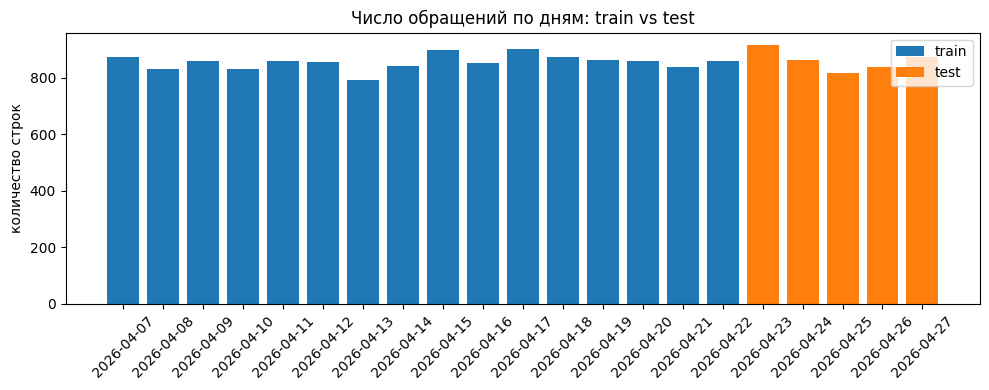

train: 2026-04-07 09:02:00 -> 2026-04-22 21:58:00
test:  2026-04-23 09:00:00 -> 2026-04-27 21:59:00


In [45]:
train_assignment_dt = pd.to_datetime(train["assignment_ts"])
test_assignment_dt = pd.to_datetime(test["assignment_ts"])

train_daily = train_assignment_dt.dt.date.value_counts().sort_index()
test_daily = test_assignment_dt.dt.date.value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(train_daily.index.astype(str), train_daily.values, label="train")
plt.bar(test_daily.index.astype(str), test_daily.values, label="test")
plt.xticks(rotation=45)
plt.ylabel("количество строк")
plt.title("Число обращений по дням: train vs test")
plt.legend()
plt.tight_layout()
plt.show()

print(f"train: {train_assignment_dt.min()} -> {train_assignment_dt.max()}")
print(f"test:  {test_assignment_dt.min()} -> {test_assignment_dt.max()}")

**ВЫВОД**: `train` --- 16 дней (07.04-22.04), `test` --- 5 дней (23.04-27.04), строго после `train`, без пересечения. Сплит по времени уже чистый.

##### Исследуем стационарность target

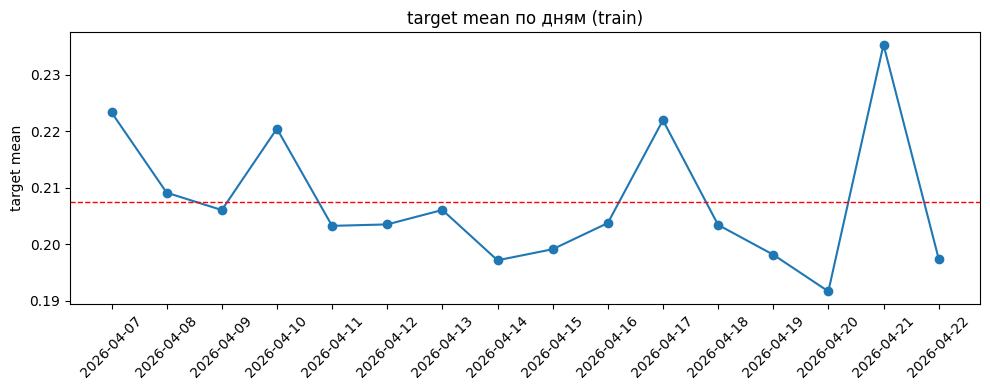

count    16.000000
mean      0.207492
std       0.011819
min       0.191638
25%       0.198869
50%       0.203628
75%       0.211971
max       0.235364
Name: target, dtype: float64


In [46]:
daily_target_rate = train.groupby(train_assignment_dt.dt.date)[TARGET].mean()

plt.figure(figsize=(10, 4))
plt.plot(daily_target_rate.index.astype(str), daily_target_rate.values, marker="o")
plt.axhline(target.mean(), color="red", linestyle="--", linewidth=1)
plt.xticks(rotation=45)
plt.ylabel("target mean")
plt.title("target mean по дням (train)")
plt.tight_layout()
plt.show()

print(daily_target_rate.describe())

**ВЫВОД**: `target_rate` колеблется в диапазоне ~19-24%, std ≈ 1.2%, вокруг среднего 20.7% --- заметного тренда или дрейфа за 16 дней train нет, целевая переменная стационарна.

##### Исследуем стационарность ключевых признаков

Проверяю топ-5 ключевых признаков по корреляции с таргетом из `target_corr_ratio` (EDA1.3) --- среднее значение по дням, ищем тренд/скачок за период train.

Почему именно такие топ-5? Т.к. эти признаки сильнее всего коррелируют с `target`, именно их дрейф опасен больше всего (большее влияние на `target`).

```
search_views_90d           0.272307
item_views_90d             0.265135
item_views_30d             0.253351
search_views_30d           0.251135
item_views_14d             0.251023
```

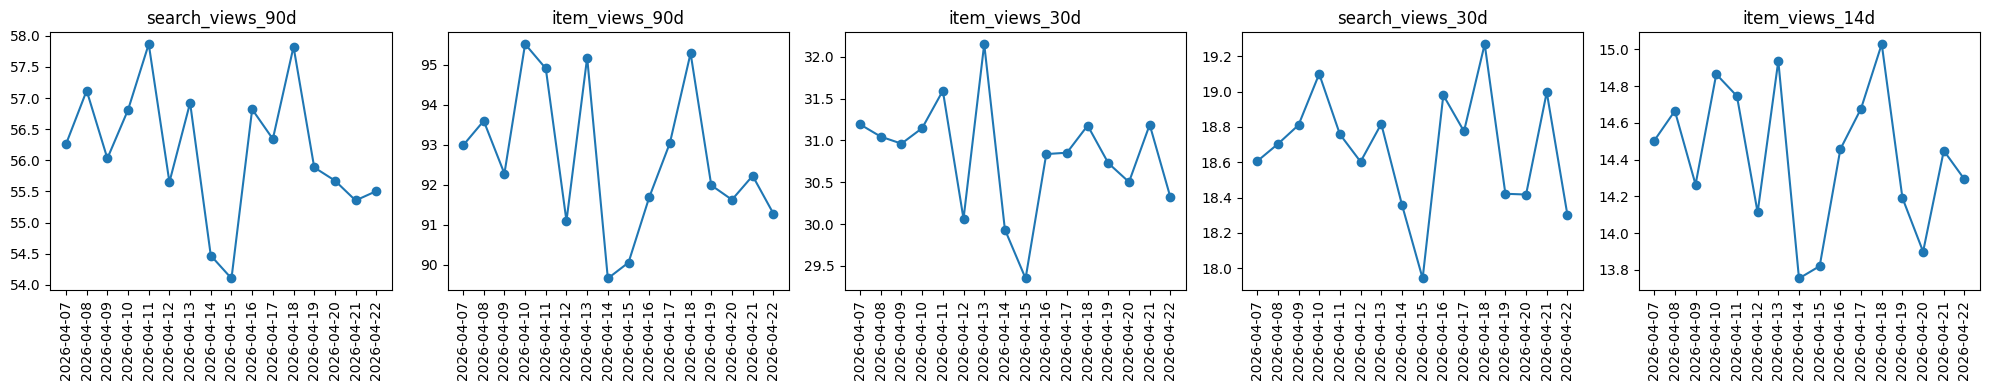

относительный разброс (std/mean) по дням:
search_views_90d    0.019
item_views_90d      0.020
item_views_30d      0.022
search_views_30d    0.018
item_views_14d      0.027
dtype: float64


In [47]:
top_stationarity_columns = target_corr_ratio.head(5).index.tolist()
daily_feature_means = train.groupby(train_assignment_dt.dt.date)[top_stationarity_columns].mean()

fig, axes = plt.subplots(1, len(top_stationarity_columns), figsize=(4 * len(top_stationarity_columns), 4))
for i, column in enumerate(top_stationarity_columns):
    axes[i].plot(daily_feature_means.index.astype(str), daily_feature_means[column], marker="o")
    axes[i].set_title(column)
    axes[i].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print("относительный разброс (std/mean) по дням:")
print((daily_feature_means.std() / daily_feature_means.mean()).round(3))

**ВЫВОД**: относительный разброс среднего по дням у всех топ-5 признаков ~2-3% --- визуально ровные линии без тренда/скачка, признаки стационарны на всём периоде train.

##### Исследуем цикличность target по часу дня и дню недели


Проверки выше смотрели тренд по календарным **дням** и сглаживали внутридневную/недельную структуру. 

Здесь проверяю цикличность: зависит ли доля успеха от часа дня и дня недели на train.

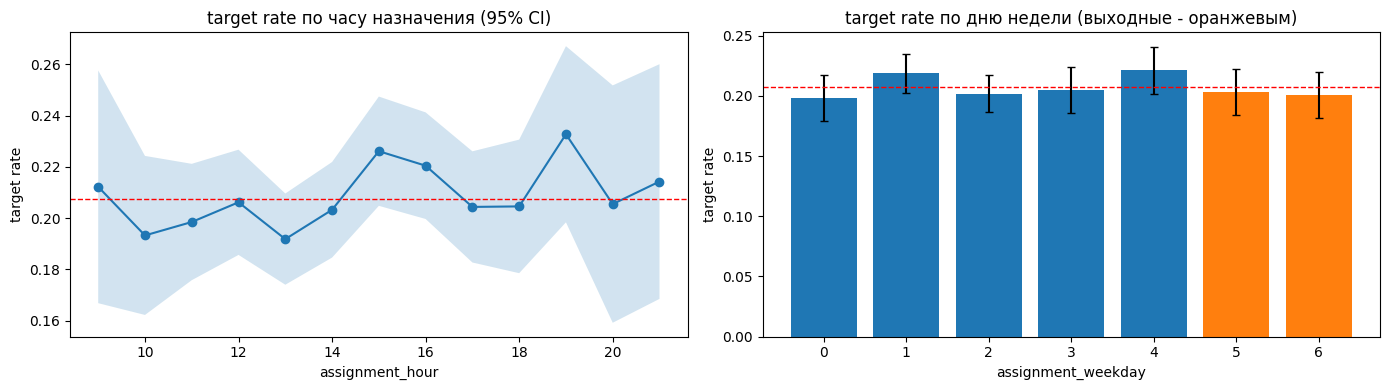

chi2 тест независимости target и assignment_hour: p-value = 0.4805
chi2 тест независимости target и assignment_weekday: p-value = 0.4271


In [48]:
def target_rate_with_ci(column):
    # доля target по группе + биномиальная стандартная ошибка SE = sqrt(p(1-p)/n)
    stats = train.groupby(column)[TARGET].agg(mean="mean", count="count")
    stats["se"] = (stats["mean"] * (1 - stats["mean"]) / stats["count"]) ** 0.5
    return stats

hour_stats = target_rate_with_ci("assignment_hour")
weekday_stats = target_rate_with_ci("assignment_weekday")
base_rate = target.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# слева: внутридневная кривая target rate с полосой ±1.96*SE (95% CI) - видна ли форма (пик/спад)
axes[0].plot(hour_stats.index, hour_stats["mean"], marker="o")
axes[0].fill_between(
    hour_stats.index,
    hour_stats["mean"] - 1.96 * hour_stats["se"],
    hour_stats["mean"] + 1.96 * hour_stats["se"],
    alpha=0.2,
)
axes[0].axhline(base_rate, color="red", linestyle="--", linewidth=1)
axes[0].set_title("target rate по часу назначения (95% CI)")
axes[0].set_xlabel("assignment_hour")
axes[0].set_ylabel("target rate")

# справа: по дню недели с усами ±1.96*SE, выходные (5,6 = is_weekend) выделены цветом
weekend_colors = ["tab:orange" if day in (5, 6) else "tab:blue" for day in weekday_stats.index]
axes[1].bar(weekday_stats.index, weekday_stats["mean"], yerr=1.96 * weekday_stats["se"],
            color=weekend_colors, capsize=3)
axes[1].axhline(base_rate, color="red", linestyle="--", linewidth=1)
axes[1].set_title("target rate по дню недели (выходные - оранжевым)")
axes[1].set_xlabel("assignment_weekday")
axes[1].set_ylabel("target rate")

plt.tight_layout()
plt.show()

# тест независимости target от часа/дня недели 
# (H0: доля target не зависит от группы)
for column in ["assignment_hour", "assignment_weekday"]:
    p_value = chi2_contingency(pd.crosstab(target, train[column]))[1]
    print(f"chi2 тест независимости target и {column}: p-value = {p_value:.4f}")

**ВЫВОД**: цикличности target по времени нет. Оба теста независимости незначимы (p-value 0.48 по часу, 0.43 по дню недели) --- гипотезу о независимости доли от часа/дня не отвергаем. Видимый разброс (19.2-23.3% по часам, 19.9-22.1% по дням) укладывается в биномиальный шум (полосы/усы ±1.96·SE перекрывают базовую линию), выходные vs будни --- 20.2% vs 20.9%, почти совпадают. Т.е. подтверждается ранее сделанный вывод о том, час и день недели как отдельные фичи для target бесполезны.

### EDA1.5

##### Базовый анализ датасета events.csv

In [59]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   lead_id         254705 non-null  object 
 1   user_id         254705 non-null  object 
 2   event_ts        254705 non-null  object 
 3   event_type      254705 non-null  object 
 4   item_price_log  254705 non-null  float64
 5   src_slot        254705 non-null  float64
 6   ctx_seq         254705 non-null  object 
dtypes: float64(2), object(5)
memory usage: 13.6+ MB


In [98]:
events.isna().sum()

lead_id           0
user_id           0
event_ts          0
event_type        0
item_price_log    0
src_slot          0
ctx_seq           0
dtype: int64

In [61]:
events.describe(include="all").T[["count", "unique", "top", "freq"]]

,count,unique,top,freq
lead_id,254705,17988,lead_f46bfa0ae0093148,35
user_id,254705,17988,user_0012085,35
event_ts,254705,64444,2026-04-04 01:50:00,18
event_type,254705,5,item_view,120905
item_price_log,254705.0,NaN,NaN,NaN
src_slot,254705.0,NaN,NaN,NaN
ctx_seq,254705,8,c01,60728


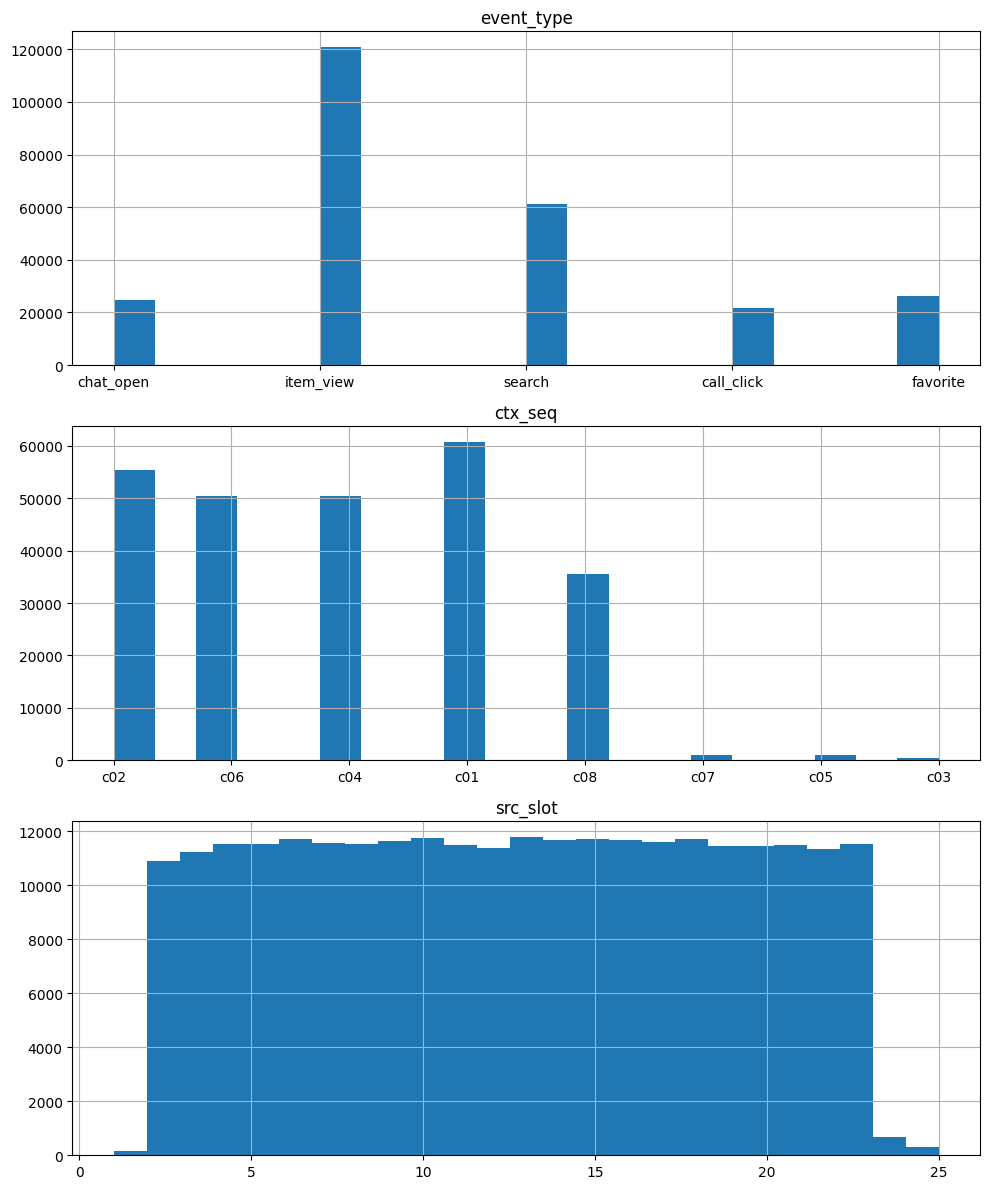

In [86]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

events['event_type'].hist(ax=axes[0], bins=20)
axes[0].set_title('event_type')

events['ctx_seq'].hist(ax=axes[1], bins=20)
axes[1].set_title('ctx_seq')

# print(events['src_slot'].value_counts().shape[0]) ==== 25
events['src_slot'].hist(ax=axes[2], bins=25)
axes[2].set_title('src_slot')

plt.tight_layout()
plt.show()

<Axes: >

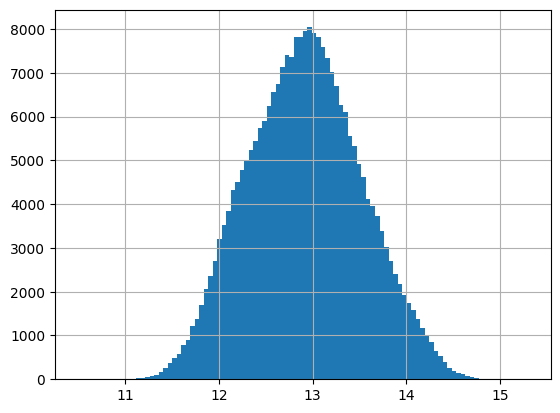

In [77]:
events["item_price_log"].hist(bins=100)
# график логарифма цены товара - распределение похоже на нормальное

In [89]:
# ключ lead_id <-> user_id: 1:1?
max_users_per_lead = events.groupby("lead_id")["user_id"].nunique().max()
max_leads_per_user = events.groupby("user_id")["lead_id"].nunique().max()
print(f"макс. user_id на один lead_id: {max_users_per_lead}, макс. lead_id на один user_id: {max_leads_per_user}")

# покрытие: доля лидов train/test, у которых есть хотя бы одно событие
event_leads = set(events["lead_id"])
print(f"доля лидов train с событиями: {train['lead_id'].isin(event_leads).mean():.4f}")
print(f"доля лидов test  с событиями: {test['lead_id'].isin(event_leads).mean():.4f}")

# сколько событий приходится на лид
print("\nчисло событий на лид:")
print(events.groupby("lead_id").size().describe())

макс. user_id на один lead_id: 1, макс. lead_id на один user_id: 1
доля лидов train с событиями: 0.9993
доля лидов test  с событиями: 0.9993

число событий на лид:
count    17988.000000
mean        14.159718
std          6.592222
min          1.000000
25%          9.000000
50%         13.000000
75%         19.000000
max         35.000000
dtype: float64


##### Джойн к train по lead_id

По условию задачи признаки из `events.csv` должны использовать только `event_ts < assignment_ts`. Проверяю напрямую: джойню `events` к `train` по `lead_id`, считаю долю событий, где `event_ts >= assignment_ts`.

<Axes: xlabel='event_ts'>

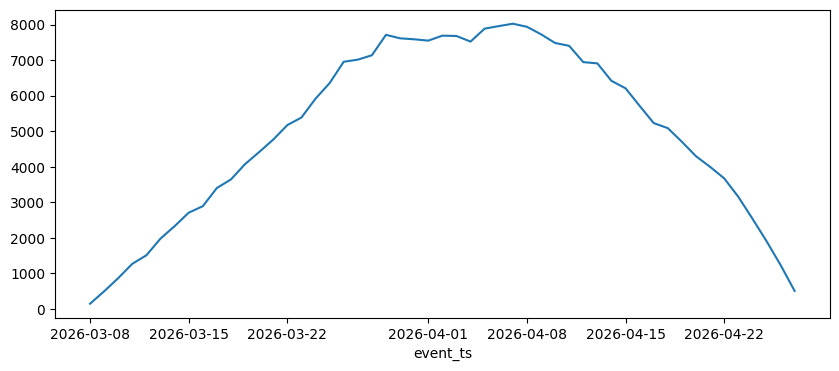

In [88]:
events_dt = pd.to_datetime(events["event_ts"])
events_daily = events_dt.dt.date.value_counts().sort_index()
events_daily.plot(figsize=(10, 4))

In [93]:
# джойн событий к train по lead_id и доля "будущих" событий (event_ts >= assignment_ts) - их использовать нельзя
train_events = events[["lead_id", "event_ts"]].merge(
    train[["lead_id", "assignment_ts"]], on="lead_id", how="inner"
)
train_events["event_ts"] = pd.to_datetime(train_events["event_ts"])
train_events["assignment_ts"] = pd.to_datetime(train_events["assignment_ts"])

is_future = train_events["event_ts"] >= train_events["assignment_ts"]
print(f"Событий приджойнено к train: {len(train_events)} из {len(events)}")
print(f"доля 'будущих' событий (event_ts >= assignment_ts): {is_future.mean():.2%}")

# у скольких лидов остаётся хотя бы одно допустимое событие (до назначения)
leads_with_history = train_events.loc[~is_future, "lead_id"].nunique()
print(f"Число лидов с >=1 событием до назначения: {leads_with_history} из {train_events['lead_id'].nunique()}")

Событий приджойнено к train: 197421 из 254705
доля 'будущих' событий (event_ts >= assignment_ts): 8.17%
Число лидов с >=1 событием до назначения: 13674 из 13685


**ВЫВОД**: 8.2% приджойненных к train событий имеют `event_ts >= assignment_ts` --- это «будущее» относительно момента назначения. При построении признаков из events их обязательно отфильтровать условием `event_ts < assignment_ts`, иначе прямой leakage. После фильтра почти у всех лидов остаётся хотя бы одно допустимое событие.

##### Можно ли пересчитать оконные счётчики из events.csv ?


В [EDA1.1](#eda11) нашел систематические нарушения вложенности окон и предположил баг пайплайна. Идея --- пересчитать оконные признаки из `events.csv`, чтобы починить нарушения из `EDA1.1` и заполнить `NaN`.

Прежде чем это делать, проверяю ключевую предпосылку: полон ли лог событий. Сравниваю готовый счётчик `item_views_90d` с числом всех `item_view` событий на лид во **всей** истории events (без окна) --- счётчик за 90 дней не может превышать полное число событий в логе.

In [ ]:
# число item_view событий на лид во всей истории events (без ограничения окна)
item_view_events_per_lead = events[events["event_type"] == "item_view"].groupby("lead_id").size()

reconstruction = train.set_index("lead_id")[["item_views_90d"]].copy()
reconstruction["item_view_events_total"] = item_view_events_per_lead
# если обращения нет в events, то счётчик событий item_view_events_total = 0 (fillna)
reconstruction["item_view_events_total"] = reconstruction["item_view_events_total"].fillna(0)

print(f"item_views_90d, среднее по train: {reconstruction['item_views_90d'].mean():.1f}")
print(f"всего item_view событий на лид (вся история events): {reconstruction['item_view_events_total'].mean():.1f}")
print(f"доля лидов, где счётчик 90d больше ВСЕХ item_view событий в логе: "
      f"{(reconstruction['item_views_90d'] > reconstruction['item_view_events_total']).mean():.1%}")

item_views_90d, среднее по train: 92.6
всего item_view событий на лид (вся история events): 6.8
доля лидов, где счётчик 90d больше ВСЕХ item_view событий в логе: 97.1%


**ВЫВОД**: Средний `item_views_90d` (≈93) на порядок больше, чем всего `item_view` событий на лид во всей истории (≈7), и у 97% лидов счётчик за 90 дней превышает **все** `item_view` события в логе. Значит, восстановить/починить оконные счётчики из events нельзя --- гипотезу о баге пайплайна из EDA1.1 этим способом не проверить. **`events.csv` --- не полный лог, а урезанная выборка.** Поэтому нарушения из `EDA1.1` и NaN придётся фиксить иначе.

### EDA1.6

##### Исследуем пересечение user_id между train и test

In [45]:
print('train rows', len(train), '| user_id nunique', train.user_id.nunique(), '| lead_id nunique', train.lead_id.nunique())
print('test  rows', len(test), '| user_id nunique', test.user_id.nunique(), '| lead_id nunique', test.lead_id.nunique())
inter = set(train.user_id) & set(test.user_id)
print('пересечение user_id train & test:', len(inter))
print('пересечение lead_id:', len(set(train.lead_id) & set(test.lead_id)))
print('дубли user_id внутри train:', train.user_id.duplicated().sum(), '| внутри test:', test.user_id.duplicated().sum())

train rows 13694 | user_id nunique 13694 | lead_id nunique 13694
test  rows 4306 | user_id nunique 4306 | lead_id nunique 4306
пересечение user_id train & test: 0
пересечение lead_id: 0
дубли user_id внутри train: 0 | внутри test: 0


**Вывод**: никакой утечки данных через пользователя быть не может